In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm import tqdm
from shapely import box
from shapely.ops import transform
import pyproj
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

from sklearn.cluster import KMeans

save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
preprocess_dir = save_dir / "preprocess"
metadata_dir = save_dir / "metadata"

# basin_file = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/reservoirs/metadata/All_MERIT_matchups.gpkg")
# subbasins = gpd.read_file(basin_file).set_index('comid')

In [2]:
subs_dir = Path("/nas/cee-water/cjgleason/ted/graph_delineator/data/clamped_manual_matchups/subbasins")
subs_list = []
for f in tqdm(list(subs_dir.glob("*.parquet"))):
    outlet_id = f.stem.split('_subbasins')[0]
    sub_gdf = gpd.read_parquet(f)
    sub_gdf['outlet_id'] = outlet_id
    subs_list.append(sub_gdf)

    # TESTING
    if len(subs_list) == 10:
        break

subbasins = pd.concat(subs_list)#.set_index('id')
subbasins = subbasins.rename(columns={'id':'site_id'}).set_index('site_id')
subbasins

  1%|          | 9/1472 [00:01<05:05,  4.79it/s]


,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,
23017799,"POLYGON ((9.02292 47.06458, 9.02792 47.06458, ...",91.771433,91.771433,original,False,23017718,EAUF-A3750050
23017798,"POLYGON ((8.00042 47.05292, 8.00875 47.05292, ...",62.684214,62.684214,original,False,23017760,EAUF-A3750050
23014085,"POLYGON ((8.37125 48.50958, 8.37208 48.50958, ...",36.620979,36.620979,original,False,23014034,EAUF-A3750050
23022409,"POLYGON ((9.85708 47.02292, 9.86208 47.02292, ...",63.530323,63.530323,original,False,23021004,EAUF-A3750050
23017790,"POLYGON ((9.28792 47.15542, 9.29042 47.15542, ...",198.555062,198.555062,original,False,23017733,EAUF-A3750050
...,...,...,...,...,...,...,...
EAUF-E2371105,"POLYGON ((3.22625 50.51457, 3.22625 50.51458, ...",81.125267,804.588829,gauge,True,EAUF-E2400411,EAUF-E2400411
EAUF-E1566010,"POLYGON ((2.69208 50.20123, 2.69209 50.20125, ...",61.071594,296.053585,gauge,True,23010106,EAUF-E2400411
EAUF-E1827020,"POLYGON ((3.61292 50.31375, 3.61296 50.31375, ...",85.551175,245.766468,gauge,True,23009989,EAUF-E2400411


In [3]:
from data import BasinDataLake
root_dir = save_dir / 'datalakes' / 'training'
store = BasinDataLake(root_dir)

In [5]:
status = store.get_processing_status(source='era5')

In [12]:
processed_basins = [] if status.empty else status.index.get_level_values('subbasin').unique().to_list()

In [13]:
processed_basins.append('23017799')

In [14]:
subbasins[~subbasins.index.isin(processed_basins)]

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,
23017798,"POLYGON ((8.00042 47.05292, 8.00875 47.05292, ...",62.684214,62.684214,original,False,23017760,EAUF-A3750050
23014085,"POLYGON ((8.37125 48.50958, 8.37208 48.50958, ...",36.620979,36.620979,original,False,23014034,EAUF-A3750050
23022409,"POLYGON ((9.85708 47.02292, 9.86208 47.02292, ...",63.530323,63.530323,original,False,23021004,EAUF-A3750050
23017790,"POLYGON ((9.28792 47.15542, 9.29042 47.15542, ...",198.555062,198.555062,original,False,23017733,EAUF-A3750050
23020440,"POLYGON ((8.20875 48.56125, 8.20958 48.56125, ...",38.673972,38.673972,original,False,23014063,EAUF-A3750050
...,...,...,...,...,...,...,...
EAUF-E2371105,"POLYGON ((3.22625 50.51457, 3.22625 50.51458, ...",81.125267,804.588829,gauge,True,EAUF-E2400411,EAUF-E2400411
EAUF-E1566010,"POLYGON ((2.69208 50.20123, 2.69209 50.20125, ...",61.071594,296.053585,gauge,True,23010106,EAUF-E2400411
EAUF-E1827020,"POLYGON ((3.61292 50.31375, 3.61296 50.31375, ...",85.551175,245.766468,gauge,True,23009989,EAUF-E2400411


In [17]:
subs_list = []
for f in tqdm(subs_dir.glob("*.parquet")):
    outlet_id = f.stem.split('_subbasins')[0]
    sub_gdf = gpd.read_parquet(f).rename(columns={'id':'site_id'})
    sub_gdf['outlet_id'] = outlet_id
    subs_list.append(sub_gdf)
subbasins = pd.concat(subs_list).set_index('site_id')

1472it [03:55,  6.26it/s]


In [20]:
subbasins[subbasins['outlet_id'] == 'USGS-07374000']

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,
74016726,"POLYGON ((-103.46542 43.06458, -103.46208 43.0...",117.317285,1.173173e+02,original,False,74016716,USGS-07374000
74046301,"POLYGON ((-104.81375 37.06292, -104.81292 37.0...",82.612304,8.261230e+01,original,False,74046218,USGS-07374000
74023259,"POLYGON ((-107.16292 41.56208, -107.16208 41.5...",95.472708,9.547271e+01,original,False,74023160,USGS-07374000
74053173,"POLYGON ((-96.65708 38.55542, -96.65375 38.555...",29.442429,2.944243e+01,original,False,74046259,USGS-07374000
74060921,"MULTIPOLYGON (((-103.76958 36.99792, -103.7687...",25.388630,2.538863e+01,original,False,74054270,USGS-07374000
...,...,...,...,...,...,...,...
USGS-07292500,"POLYGON ((-91.13375 31.24708, -91.13371 31.247...",94.249503,2.039318e+03,gauge,True,74070139,USGS-07374000
USGS-07290650,"POLYGON ((-90.69042 32.01875, -90.69125 32.018...",200.352764,1.697335e+03,gauge,True,74070171,USGS-07374000
USGS-07291000,"POLYGON ((-90.84875 31.58125, -90.84875 31.581...",76.828170,4.675708e+02,gauge,True,74070222,USGS-07374000


In [11]:
status = store.get_processing_status(source='era5')
processed_basins = [] if status.empty else status.index.get_level_values('basin').unique()

to_process = subbasins[subbasins['outlet_id'].isin(processed_basins)]
to_process

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,


In [12]:
subbasins

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,
23017799,"POLYGON ((9.02292 47.06458, 9.02792 47.06458, ...",91.771433,91.771433,original,False,23017718,EAUF-A3750050
23017798,"POLYGON ((8.00042 47.05292, 8.00875 47.05292, ...",62.684214,62.684214,original,False,23017760,EAUF-A3750050
23014085,"POLYGON ((8.37125 48.50958, 8.37208 48.50958, ...",36.620979,36.620979,original,False,23014034,EAUF-A3750050
23022409,"POLYGON ((9.85708 47.02292, 9.86208 47.02292, ...",63.530323,63.530323,original,False,23021004,EAUF-A3750050
23017790,"POLYGON ((9.28792 47.15542, 9.29042 47.15542, ...",198.555062,198.555062,original,False,23017733,EAUF-A3750050
...,...,...,...,...,...,...,...
EAUF-E2371105,"POLYGON ((3.22625 50.51457, 3.22625 50.51458, ...",81.125267,804.588829,gauge,True,EAUF-E2400411,EAUF-E2400411
EAUF-E1566010,"POLYGON ((2.69208 50.20123, 2.69209 50.20125, ...",61.071594,296.053585,gauge,True,23010106,EAUF-E2400411
EAUF-E1827020,"POLYGON ((3.61292 50.31375, 3.61296 50.31375, ...",85.551175,245.766468,gauge,True,23009989,EAUF-E2400411


In [15]:
target = 'EAUF-E2400411'
df_sorted = pd.concat([subbasins[subbasins["outlet_id"] == target], subbasins[subbasins["outlet_id"] != target]])
df_sorted

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,
23009595,"POLYGON ((3.47125 50.02458, 3.47792 50.02458, ...",76.919299,76.919299,original,False,23009357,EAUF-E2400411
23011937,"POLYGON ((3.90458 50.52542, 3.90708 50.52542, ...",27.307764,27.307764,original,False,23010219,EAUF-E2400411
23011936,"MULTIPOLYGON (((3.40875 50.46375, 3.40958 50.4...",27.563555,27.563555,original,False,EAUF-E2371105,EAUF-E2400411
23011919,"MULTIPOLYGON (((3.14625 50.48708, 3.14708 50.4...",79.843404,79.843404,original,False,23010108,EAUF-E2400411
23011864,"POLYGON ((4.13375 50.44625, 4.13458 50.44625, ...",50.507445,50.507445,original,False,23010893,EAUF-E2400411
...,...,...,...,...,...,...,...
EAUF-D0137010,"POLYGON ((3.92875 50.06125, 3.92879 50.06125, ...",67.611998,159.927340,gauge,True,23010924,EAUF-D0192230
EAUF-D0156510,"POLYGON ((4.10792 50.14708, 4.10875 50.14708, ...",56.949489,187.189034,gauge,True,EAUF-D0156560,EAUF-D0192230
EAUF-D0156560,"POLYGON ((4.06958 50.16042, 4.06958 50.15958, ...",67.495122,254.684155,gauge,True,EAUF-D0156520,EAUF-D0192230


In [16]:
type(df_sorted)

geopandas.geodataframe.GeoDataFrame

In [5]:
e5_dir = Path("/nas/cee-ice/data/ERA5-Land/")

def create_spatial_batches(gdf, batch_size):
    """
    Groups subbasins into spatially coherent batches using K-Means clustering.
    
    Returns a list of batch dictionaries, each containing the IDs and
    a single bounding box for all geometries in that batch.
    """
    n_batches = int(np.ceil(len(gdf)/batch_size))
        
    # Get centroids for clustering
    centroids = np.array([list(p.coords)[0] for p in gdf.geometry.centroid])
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_batches, random_state=42, n_init=10)
    gdf['cluster'] = kmeans.fit_predict(centroids)
    
    batches = []
    for i in range(n_batches):
        batch_gdf = gdf[gdf['cluster'] == i]
        if batch_gdf.empty:
            continue
        
        # Get all COMIDs in this cluster
        batch_ids = batch_gdf.index.tolist()
        
        # Calculate a single, unified bounding box for the entire batch
        # Add a 0.1 degree padding to ensure all grid cells are included
        min_lon, min_lat, max_lon, max_lat = batch_gdf.total_bounds
        padding = 0.1
        batch_bounds = (
            np.floor((min_lon - padding) * 10) / 10,
            np.floor((min_lat - padding) * 10) / 10,
            np.ceil((max_lon + padding) * 10) / 10,
            np.ceil((max_lat + padding) * 10) / 10,
        )
        
        batches.append({
            "ids": batch_ids,
            "geoms": batch_gdf.geometry,
            "bounds": batch_bounds
        })
        
    return batches


def open_monthly_files(year, month):
    """Loads and merges the original monthly ERA5 files."""
    fps = [
        e5_dir / "accumulated" / f"{year}_{month:02d}.nc",
        e5_dir / "average" / f"{year}_{month:02d}.nc"
    ]
    datasets = [xr.open_dataset(fp) for fp in fps]
    ds = xr.merge(datasets).drop_vars(['expver','number'], errors='ignore')
    return ds


def subset_ds_by_bounds(ds, bounds):
    """Subset dataset by spatial bounds."""
    min_lon, min_lat, max_lon, max_lat = bounds
    return ds.sel(latitude=slice(max_lat, min_lat), longitude=slice(min_lon, max_lon))


def get_weight_matrix(ds_subset, watershed_geom):
    """Calculate weight matrix for a single watershed."""
    lat, lon = ds_subset['latitude'].values, ds_subset['longitude'].values
    lat_res, lon_res = 0.1, 0.1
    
    watershed_proj = watershed_geom.to_crs(epsg=3857)
    transformer = pyproj.Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)
    
    coverage_fractions = np.zeros((len(lat), len(lon)))
    
    for i, lat_val in enumerate(lat):
        for j, lon_val in enumerate(lon):
            pixel_box = box(lon_val - lon_res/2, lat_val - lat_res/2,
                            lon_val + lon_res/2, lat_val + lat_res/2)
            pixel_box_proj = transform(transformer.transform, pixel_box)
            
            intersection_area = watershed_proj.intersection(pixel_box_proj).area
            pixel_area = pixel_box_proj.area
            coverage_fractions[i, j] = (intersection_area / pixel_area).iloc[0] if pixel_area > 0 else 0
    
    return xr.DataArray(
        coverage_fractions,
        dims=["latitude", "longitude"],
        coords={"latitude": lat, "longitude": lon}
    )


def get_results_df(ds_sub, weights):
    """Calculate weighted statistics."""
    dims = ["latitude", "longitude"]
    ds_sub_w = ds_sub.weighted(weights)
    
    mean_df = (ds_sub_w.mean(dim=dims).to_dataframe()
               .rename(lambda n: n+"_mean", axis=1))
    var_df = (ds_sub_w.var(dim=dims).to_dataframe()
               .rename(lambda n: n+"_var", axis=1))
    
    return pd.concat([mean_df, var_df], axis=1)


def process_spatial_batch(spatial_batch: dict, start_date, end_date):
    """
    Processes a spatially coherent batch of COMIDs.
    Loads regional data once per month and applies it to all COMIDs in the batch.
    """
    batch_ids = spatial_batch['ids']
    batch_geoms = gpd.GeoDataFrame(spatial_batch['geoms'])
    batch_bounds = spatial_batch['bounds']

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    # Pre-calculate weight matrices for all watersheds in the batch
    # This requires a sample dataset to get the grid right
    print(f"Pre-calculating weight matrices for batch...")
    sample_ds = open_monthly_files(start_date.year, start_date.month)
    sample_ds_sub = subset_ds_by_bounds(sample_ds, batch_bounds)
    
    weights_map = {}
    for comid, row in batch_geoms.iterrows():
        watershed = gpd.GeoDataFrame([row], crs=batch_geoms.crs)
        weights_map[comid] = get_weight_matrix(sample_ds_sub, watershed)
    sample_ds.close()
    print(f"Weight matrices calculated.")

    # Generate date range
    date_range = pd.date_range(start=start_date, end=end_date, freq="MS")
    
    # This dictionary will hold the time-series data for each COMID
    comid_results = {comid: [] for comid in batch_ids}

    # Outer loop is TIME
    for date in date_range:
        # Load the full monthly file and subset to the BATCH's bounds ONCE
        ds_full = open_monthly_files(date.year, date.month)
        ds_region = subset_ds_by_bounds(ds_full, batch_bounds)
        
        # Inner loop is COMID (processing from in-memory data)
        for comid in batch_ids:
            weights = weights_map[comid]
            
            # Ensure weights align with the regional data subset
            weights_aligned = weights.reindex_like(ds_region, method='nearest', tolerance=0.01)
            
            df_month = get_results_df(ds_region, weights_aligned)
            comid_results[comid].append(df_month)
        
        ds_full.close()
        ds_region.close()

    cat_dfs = {}
    for comid, df_list in comid_results.items():
        cat_dfs[comid] = pd.concat(df_list, axis=0)
    return cat_dfs

In [6]:
status = store.get_processing_status(source='era5')
processed_basins = [] if status.empty else status['basin'].unique

to_process = subbasins[~subbasins.index.isin(processed_basins)]
to_process

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown,outlet_id
site_id,,,,,,,
23017799,"POLYGON ((9.02292 47.06458, 9.02792 47.06458, ...",91.771433,91.771433,original,False,23017718,EAUF-A3750050
23017798,"POLYGON ((8.00042 47.05292, 8.00875 47.05292, ...",62.684214,62.684214,original,False,23017760,EAUF-A3750050
23014085,"POLYGON ((8.37125 48.50958, 8.37208 48.50958, ...",36.620979,36.620979,original,False,23014034,EAUF-A3750050
23022409,"POLYGON ((9.85708 47.02292, 9.86208 47.02292, ...",63.530323,63.530323,original,False,23021004,EAUF-A3750050
23017790,"POLYGON ((9.28792 47.15542, 9.29042 47.15542, ...",198.555062,198.555062,original,False,23017733,EAUF-A3750050
...,...,...,...,...,...,...,...
EAUF-E2371105,"POLYGON ((3.22625 50.51457, 3.22625 50.51458, ...",81.125267,804.588829,gauge,True,EAUF-E2400411,EAUF-E2400411
EAUF-E1566010,"POLYGON ((2.69208 50.20123, 2.69209 50.20125, ...",61.071594,296.053585,gauge,True,23010106,EAUF-E2400411
EAUF-E1827020,"POLYGON ((3.61292 50.31375, 3.61296 50.31375, ...",85.551175,245.766468,gauge,True,23009989,EAUF-E2400411


In [6]:
import rasterio.features
from rasterio.transform import from_origin

def get_weight_matrix_fast(ds_subset, watershed_geom, scale_factor=10):
    """
    Calculates fractional coverage using super-sampling rasterization.
    
    Args:
        ds_subset: xarray Dataset/DataArray with latitude/longitude coords
        watershed_geom: GeoDataFrame containing the watershed polygon
        scale_factor: Factor to upsample for precision (10 = 1/100th precision)
    """
    # 1. Extract coordinates and resolution
    # Assumes 1D coordinates for lat/lon
    lat = ds_subset['latitude'].values
    lon = ds_subset['longitude'].values
    
    # Calculate resolution (assuming uniform grid)
    # ERA5 lat is usually descending, so d_lat might be negative
    d_lat = lat[1] - lat[0]
    d_lon = lon[1] - lon[0]
    
    # 2. Define Coarse Dimensions
    height = len(lat)
    width = len(lon)
    
    # 3. Define Fine Dimensions (Super-sampling)
    fine_height = height * scale_factor
    fine_width = width * scale_factor
    
    # 4. Create Affine Transform for the FINE grid
    # We shift the origin to the top-left corner of the first pixel
    # Note: We subtract/add half a pixel to move from center to corner
    west = lon[0] - d_lon / 2
    north = lat[0] - d_lat / 2
    
    # The fine resolution is the coarse resolution divided by the scale factor
    fine_transform = from_origin(
        west, 
        north, 
        d_lon / scale_factor, 
        d_lat / scale_factor # rasterio handles negative dy correctly
    )
    
    # 5. Rasterize onto the fine grid (Binary 0/1)
    # We use the projected geometry if possible, but rasterio expects 
    # the geometry coords to match the transform coords (Lat/Lon here).
    # Ensure watershed_geom is EPSG:4326 before passing in.
    if watershed_geom.crs != "EPSG:4326":
        watershed_geom = watershed_geom.to_crs("EPSG:4326")
        
    mask_fine = rasterio.features.rasterize(
        shapes=[(watershed_geom.geometry.iloc[0], 1)],
        out_shape=(fine_height, fine_width),
        transform=fine_transform,
        fill=0,
        all_touched=False,  # We rely on high-res center-points for coverage
        dtype=np.float32
    )
    
    # 6. Aggregate (downsample) to coarse grid
    # Reshape to (Coarse_H, Factor, Coarse_W, Factor)
    # Then take the mean over the two 'Factor' axes
    mask_coarse = mask_fine.reshape(
        height, scale_factor, width, scale_factor
    ).mean(axis=(1, 3))
    
    # 7. Return as DataArray matching input ds
    return xr.DataArray(
        mask_coarse,
        dims=("latitude", "longitude"),
        coords={"latitude": lat, "longitude": lon},
        name="weights"
    )

In [8]:
status = store.get_processing_status(source='era5')
processed_basins = [] if status.empty else status['basin'].unique()
to_process = subbasins[~subbasins.index.isin(processed_basins)]

for basin_name, basin_gdf in to_process.groupby('outlet_id'):
    print(f"Starting basin {basin_name}")
    batches = create_spatial_batches(basin_gdf, 16)
    print(f"  Split basin into {len(batches)} batches")

    for batch in tqdm(batches):
        results = process_spatial_batch(
            batch,
            '2020-01-01',
            '2020-02-01'
        )
        break
    break
    

Starting basin EAUF-A3750050


/tmp/ipykernel_1366715/1169302799.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = np.array([list(p.coords)[0] for p in gdf.geometry.centroid])


  Split basin into 41 batches


  0%|          | 0/41 [00:00<?, ?it/s]

Pre-calculating weight matrices for batch...
Weight matrices calculated.


  0%|          | 0/41 [00:10<?, ?it/s]


In [10]:
spatial_batch = batch
start_date = '2020-01-01'
end_date = '2020-02-01'

batch_ids = spatial_batch['ids']
batch_geoms = gpd.GeoDataFrame(spatial_batch['geoms'])
batch_bounds = spatial_batch['bounds']

start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

# Pre-calculate weight matrices for all watersheds in the batch
# This requires a sample dataset to get the grid right
print(f"Pre-calculating weight matrices for batch...")
sample_ds = open_monthly_files(start_date.year, start_date.month)
sample_ds_sub = subset_ds_by_bounds(sample_ds, batch_bounds)

weights_map = {}
for comid, row in batch_geoms.iterrows():
    watershed = gpd.GeoDataFrame([row], crs=batch_geoms.crs)
    weights_map[comid] = get_weight_matrix(sample_ds_sub, watershed)

Pre-calculating weight matrices for batch...


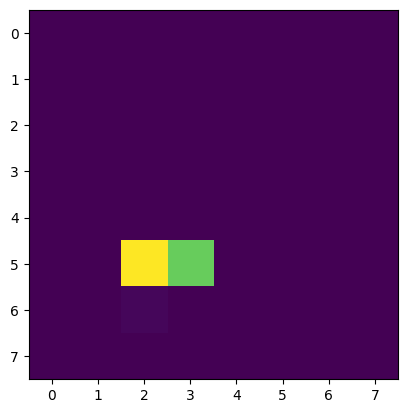

In [15]:
import matplotlib.pyplot as plt

plt.imshow(weights_map[comid].to_numpy())

<Axes: xlabel='valid_time'>

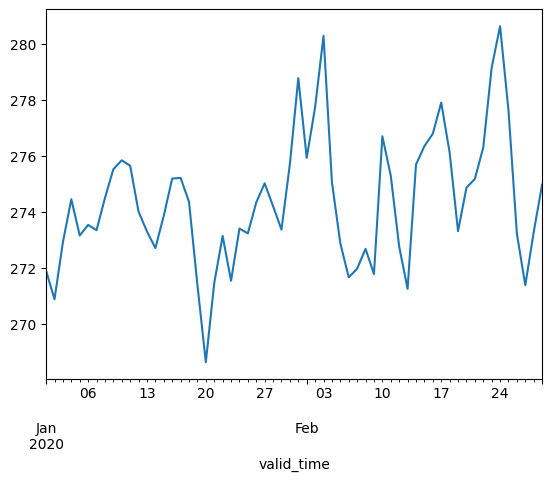

In [13]:
results['23017708']['t2m_mean'].plot()

In [ ]:
all_batches = []
for basin_name, basin_gdf in tqdm(to_process.groupby('outlet_id')):
    batches = create_spatial_batches(basin_gdf, 16)
    for b in batches:
        all_batches.append((basin_name, b))
    # if len(batches)>1:
    #     break

    # if len(all_batches)>30:
    #     break


In [55]:
from dask.distributed import Client, as_completed
from dask_jobqueue import SLURMCluster

ImportError: dask.distributed is not installed.

Please either conda or pip install distributed:

  conda install dask distributed             # either conda install
  python -m pip install "dask[distributed]" --upgrade    # or pip install

In [47]:
all_batches[0][1]

{'ids': ['56150341',
  '56150344',
  '56150871',
  '56150898',
  '56150932',
  '56151111',
  '56151157',
  '56151379',
  '56151534',
  '56154788',
  '56156020',
  'ABOM-100288010',
  'ABOM-101896010',
  'ABOM-102903010',
  'ABOM-102984010',
  'ABOM-97444010'],
 'geoms': comid
 56150341          MULTIPOLYGON (((116.25208 -32.91875, 116.25125...
 56150344          MULTIPOLYGON (((116.42708 -32.95875, 116.42708...
 56150871          MULTIPOLYGON (((116.42875 -32.84208, 116.42875...
 56150898          MULTIPOLYGON (((116.70958 -32.75292, 116.70875...
 56150932          MULTIPOLYGON (((116.86875 -32.76375, 116.86875...
 56151111          MULTIPOLYGON (((116.77375 -32.86375, 116.76792...
 56151157          MULTIPOLYGON (((117.08292 -32.65458, 117.08292...
 56151379          MULTIPOLYGON (((117.37625 -32.83542, 117.37625...
 56151534          MULTIPOLYGON (((116.55542 -32.77875, 116.55542...
 56154788          MULTIPOLYGON (((116.82958 -33.17042, 116.82958...
 56156020          MULTIPOLYGON (

In [6]:
results['ABOM-97444010']

,ssrd_mean,strd_mean,ro_mean,sro_mean,e_mean,tp_mean,t2m_mean,d2m_mean,fal_mean,sp_mean,ssrd_var,strd_var,ro_var,sro_var,e_var,tp_var,t2m_var,d2m_var,fal_var,sp_var
valid_time,,,,,,,,,,,,,,,,,,,,
2020-01-01,3.324392e+07,2.776505e+07,0.000008,0.000000e+00,-0.001159,8.523463e-07,296.115914,283.759036,0.113176,98003.682494,1.525451e+09,4.933858e+09,3.543706e-11,0.000000e+00,2.445995e-08,0.000000e+00,0.116333,0.145891,0.000101,81566.262367
2020-01-02,3.258692e+07,2.889416e+07,0.000008,0.000000e+00,-0.001140,2.139807e-06,291.028574,283.205026,0.113304,98130.688434,4.920413e+08,9.245106e+09,3.413993e-11,0.000000e+00,2.152948e-08,0.000000e+00,0.096500,0.099020,0.000101,83618.010790
2020-01-03,2.563287e+07,2.880397e+07,0.000009,3.577655e-07,-0.000869,2.026716e-04,288.246249,275.635446,0.113430,98656.428943,5.860112e+10,6.141630e+08,3.245300e-11,1.473872e-14,1.458645e-08,2.681553e-09,0.098350,0.053819,0.000101,85000.874600
2020-01-04,2.360289e+07,2.598892e+07,0.000008,1.533841e-07,-0.000729,8.561527e-05,291.487310,273.894622,0.113558,98624.069062,3.995086e+11,1.999513e+10,3.185935e-11,1.554197e-14,1.386029e-08,4.482660e-09,0.026604,0.243668,0.000101,82347.700579
2020-01-05,3.375689e+07,2.547441e+07,0.000008,0.000000e+00,-0.001022,2.581446e-06,297.071659,278.967316,0.113683,98127.863193,8.692825e+08,7.005869e+09,3.136960e-11,0.000000e+00,2.145372e-08,0.000000e+00,0.052715,0.149700,0.000101,78556.163108
2020-01-06,3.298480e+07,2.856133e+07,0.000008,0.000000e+00,-0.001020,1.718958e-06,298.308401,281.026954,0.113809,97844.779376,5.450582e+08,5.712399e+09,3.031153e-11,0.000000e+00,1.394777e-08,4.484155e-44,0.048787,0.191553,0.000101,77849.325547
2020-01-07,3.245600e+07,2.953366e+07,0.000008,0.000000e+00,-0.001077,8.523463e-07,297.199307,282.611985,0.113934,97481.731439,8.822800e+08,5.377294e+09,2.928866e-11,0.000000e+00,1.458151e-08,0.000000e+00,0.136803,0.247598,0.000101,78266.501854
2020-01-08,3.253307e+07,2.902613e+07,0.000008,0.000000e+00,-0.000998,0.000000e+00,294.797053,284.488663,0.114062,97630.743227,3.201206e+09,4.577394e+09,2.820583e-11,0.000000e+00,1.372042e-08,0.000000e+00,0.096539,0.061125,0.000101,80304.088680
2020-01-09,3.241272e+07,2.845800e+07,0.000008,0.000000e+00,-0.000958,0.000000e+00,293.093542,280.104191,0.114188,98246.689782,9.968543e+08,9.507617e+09,2.724158e-11,0.000000e+00,1.976459e-08,0.000000e+00,0.176508,0.012512,0.000101,81586.847085


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 6))

for i, batch in enumerate(batches):
    xmin, ymin, xmax, ymax = batch['batch_bounds']
    width = xmax - xmin
    height = ymax - ymin

    rect = patches.Rectangle(
        (xmin, ymin), width, height,
        linewidth=1.5, edgecolor='C0',
        facecolor='C0', alpha=0.3, label=f"Batch {i+1}" if i == 0 else None
    )
    ax.add_patch(rect)

# Make it look nice
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Batch Bounding Boxes")
ax.autoscale()
ax.legend()

plt.show()